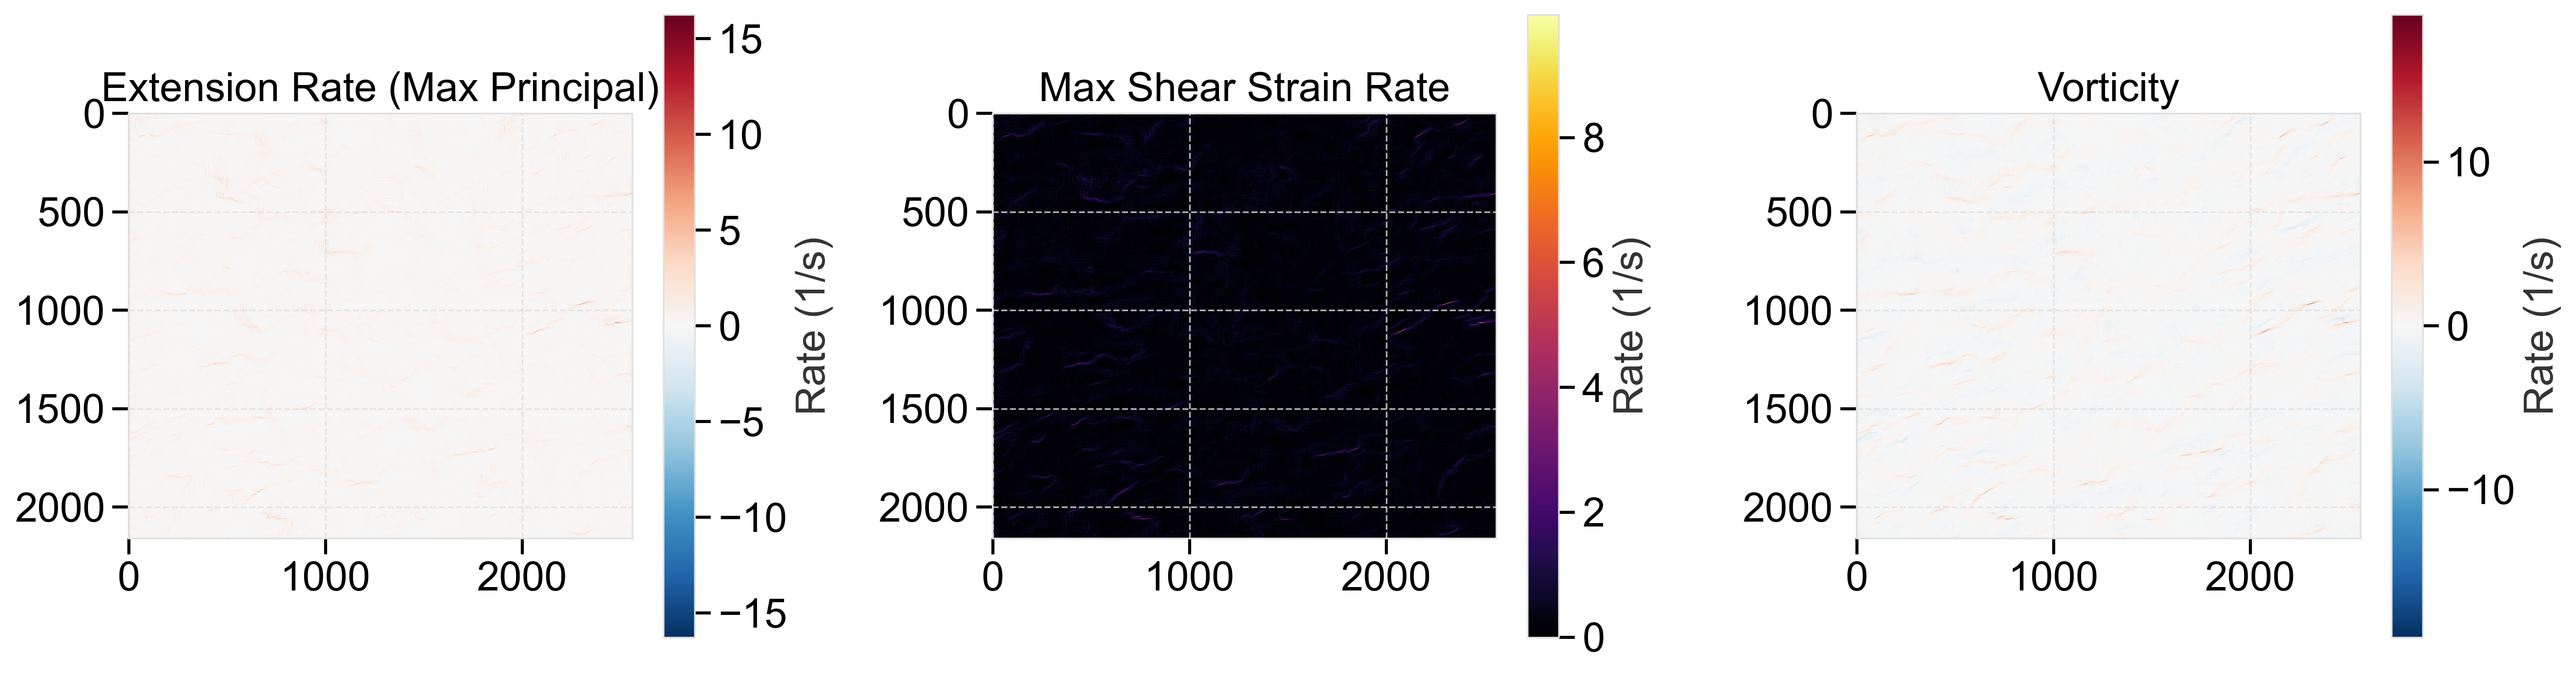

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import h5py
import pandas as pd
from pathlib import Path
import os

plt.style.use('../libs/my_style.mplstyle')

root = Path('/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads')
#root = Path('/Volumes/data/Sasaki/MTsingleBeads')

folder = root / "control/MTs8uM/20260624/MTs8uM002"

frame = 2
shared_scale = 0.5 

# データの読み込み（例として20フレーム目）
with h5py.File(str(folder / "vortex.h5"), 'r') as f:
    ext_frame = f['extension_rate'][frame].astype(float)
    shear_frame = f['strain_rate'][frame].astype(float)
    vort_frame = f['vorticity'][frame].astype(float)
    f.flush()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 第一主ひずみ速度（伸長・圧縮）
v_max = max(abs(ext_frame.min()), abs(ext_frame.max()))
im1 = axes[0].imshow(ext_frame, cmap='RdBu_r', vmin=-v_max, vmax=v_max)
axes[0].set_title('Extension Rate (Max Principal)')
fig.colorbar(im1, ax=axes[0], label='Rate (1/s)')

# 最大せん断ひずみ速度
im2 = axes[1].imshow(shear_frame, cmap='inferno')
axes[1].set_title('Max Shear Strain Rate')
fig.colorbar(im2, ax=axes[1], label='Rate (1/s)')

# 渦度 (Vorticity)
vort_max = max(abs(vort_frame.min()), abs(vort_frame.max()))
im3 = axes[2].imshow(vort_frame, cmap='RdBu_r', vmin=-vort_max, vmax=vort_max)
axes[2].set_title('Vorticity')
fig.colorbar(im3, ax=axes[2], label='Rate (1/s)')


plt.tight_layout()
plt.show()


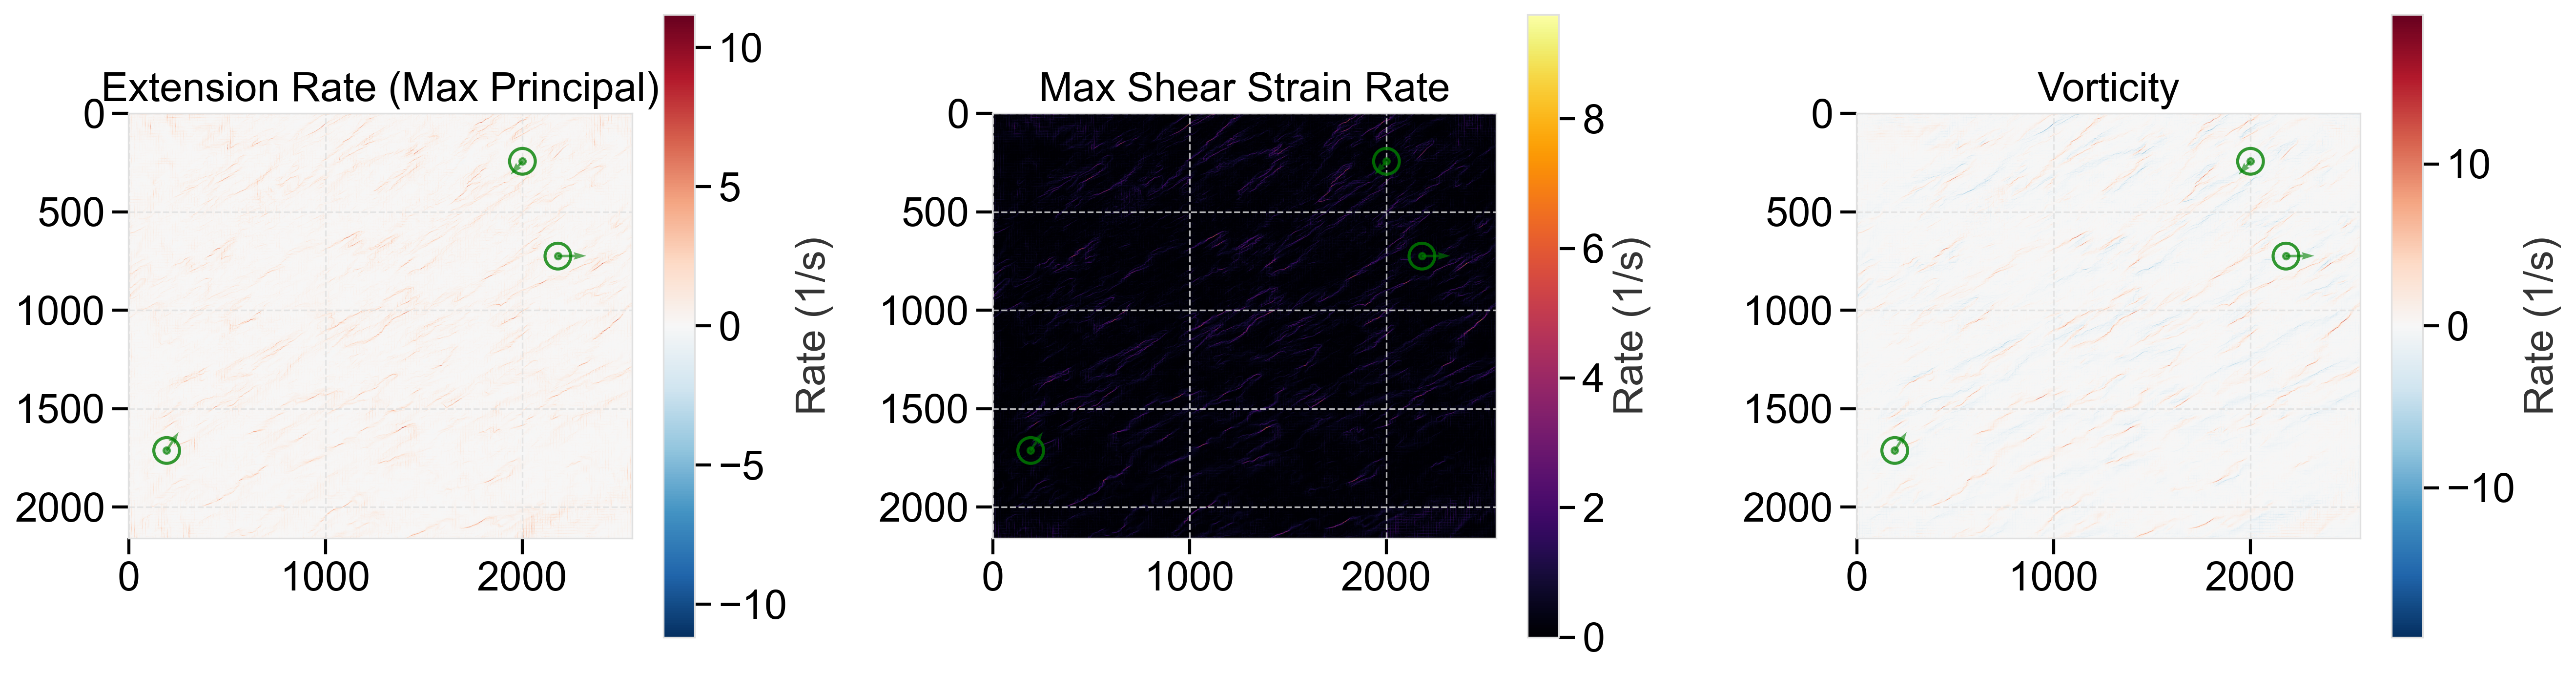

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import h5py
import pandas as pd
from pathlib import Path
import os

plt.style.use('../libs/my_style.mplstyle')

root = Path('/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads')
root = Path('/Volumes/data/Sasaki/MTsingleBeads')

folder = root / "beads7um" / "20260608" / "beads7um"
beads = pd.read_csv(folder / "beads_tracks.csv")

frame = 19
shared_scale = 0.5 

# ビーズのサイズとスケールの設定
bead_radius_um = 7.2
pixel_scale = 0.11  # um/px
bead_radius_px = bead_radius_um / pixel_scale

# データの読み込み（例として20フレーム目）
with h5py.File(str(folder / "voltex.h5"), 'r') as f:
    ext_frame = f['extension_rate'][frame].astype(float)
    shear_frame = f['strain_rate'][frame].astype(float)
    vort_frame = f['vorticity'][frame].astype(float)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 第一主ひずみ速度（伸長・圧縮）
v_max = max(abs(ext_frame.min()), abs(ext_frame.max()))
im1 = axes[0].imshow(ext_frame, cmap='RdBu_r', vmin=-v_max, vmax=v_max)
axes[0].set_title('Extension Rate (Max Principal)')
fig.colorbar(im1, ax=axes[0], label='Rate (1/s)')

# 最大せん断ひずみ速度
im2 = axes[1].imshow(shear_frame, cmap='inferno')
axes[1].set_title('Max Shear Strain Rate')
fig.colorbar(im2, ax=axes[1], label='Rate (1/s)')

# 渦度 (Vorticity)
vort_max = max(abs(vort_frame.min()), abs(vort_frame.max()))
im3 = axes[2].imshow(vort_frame, cmap='RdBu_r', vmin=-vort_max, vmax=vort_max)
axes[2].set_title('Vorticity')
fig.colorbar(im3, ax=axes[2], label='Rate (1/s)')

# ビーズの運動方向（フレーム0からフレームdtへの変位）を計算
dt = 1 # 何フレーム先との差分をとるか
bx, by, b_dx, b_dy = [], [], [], []

# フレーム0に存在する全パーティクルについて
for p in beads[beads['frame'] == frame]['particle'].unique():
    track = beads[beads['particle'] == p]
    f0_data = track[track['frame'] == frame]
    ft_data = track[track['frame'] == dt]
    
    if not f0_data.empty and not ft_data.empty:
        x0, y0 = f0_data['x'].values[0], f0_data['y'].values[0]
        xt, yt = ft_data['x'].values[0], ft_data['y'].values[0]
        
        bx.append(x0)
        by.append(y0)
        b_dx.append(xt - x0)
        b_dy.append(yt - y0)

# ビーズの運動方向と大きさを描画
if len(bx) > 0:
    for i in range(3):
        # 矢印を描画
        axes[i].quiver(bx, by, b_dx, b_dy, color='green', width=0.005,
                angles='xy', scale_units='xy', scale=shared_scale, label=f'Bead Motion (dt={dt})', alpha=0.6)
        
        # 初期位置を中心にビーズの実際の大きさの円を描画
        for x, y in zip(bx, by):
            circle = patches.Circle((x, y), bead_radius_px, color='green', fill=False, zorder=5, linewidth=1.5, alpha=0.8)
            axes[i].add_patch(circle)
        
        # 中心位置を小さな点で強調
        axes[i].scatter(bx, by, color='green', s=10, zorder=5, alpha=0.6)

plt.tight_layout()
plt.show()
